# **Classification of Maternal Health Risk Levels Using Physiological Clinical Data**

# **Installation and Data Loading**

In [1]:
!pip install ucimlrepo

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Fetch dataset
maternal_health_risk = fetch_ucirepo(id=863)
X = maternal_health_risk.data.features
y = maternal_health_risk.data.targets

# Combine into one dataframe for cleaning and EDA
df = pd.concat([X, y], axis=1)
print(f"Initial Dataset shape: {df.shape}")

Initial Dataset shape: (1014, 7)


# **Data Cleaning & Handling Duplicates**

In [2]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check and remove duplicates
duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicate_count}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Missing values:
 Age            0
SystolicBP     0
DiastolicBP    0
BS             0
BodyTemp       0
HeartRate      0
RiskLevel      0
dtype: int64

Number of duplicate rows: 562
Shape after removing duplicates: (452, 7)


In [6]:
import numpy as np

# 1. Blood Pressure Indicators
# Pulse Pressure
df['PulsePressure'] = df['SystolicBP'] - df['DiastolicBP']

# Mean Arterial Pressure (MAP)
# Formula: (Systolic + 2*Diastolic) / 3
df['MAP'] = (df['SystolicBP'] + 2 * df['DiastolicBP']) / 3

# 2. Heart and Metabolic Indicators
# Shock Index (Heart Rate / Systolic BP)
df['ShockIndex'] = df['HeartRate'] / df['SystolicBP']

# 3. Categorical Binning (Turning continuous data into clinical groups)
# Temperature: Normal (under 98.6), Elevated (98.6-100), Fever (100+)
df['IsFever'] = df['BodyTemp'].apply(lambda x: 1 if x >= 100 else 0)

# Blood Sugar (BS) Risk
# Standard threshold for concern is often around 7.8 mmol/L
df['HighBS'] = df['BS'].apply(lambda x: 1 if x > 7.8 else 0)

# 4. Age-Based Interaction
# Risk often increases with age and high blood pressure combined
df['Age_BP_Interaction'] = df['Age'] * df['SystolicBP']

print(f"New Dataset shape: {df.shape}")
print(df.head())

New Dataset shape: (452, 13)
   Age  SystolicBP  DiastolicBP    BS  BodyTemp  HeartRate  RiskLevel  \
0   25         130           80  15.0      98.0         86  high risk   
1   35         140           90  13.0      98.0         70  high risk   
2   29          90           70   8.0     100.0         80  high risk   
3   30         140           85   7.0      98.0         70  high risk   
4   35         120           60   6.1      98.0         76   low risk   

   PulsePressure         MAP  ShockIndex  IsFever  HighBS  Age_BP_Interaction  
0             50   96.666667    0.661538        0       1                3250  
1             50  106.666667    0.500000        0       1                4900  
2             20   76.666667    0.888889        1       1                2610  
3             55  103.333333    0.500000        0       0                4200  
4             60   80.000000    0.633333        0       0                4200  


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 452 non-null    int64  
 1   SystolicBP          452 non-null    int64  
 2   DiastolicBP         452 non-null    int64  
 3   BS                  452 non-null    float64
 4   BodyTemp            452 non-null    float64
 5   HeartRate           452 non-null    int64  
 6   RiskLevel           452 non-null    object 
 7   PulsePressure       452 non-null    int64  
 8   MAP                 452 non-null    float64
 9   ShockIndex          452 non-null    float64
 10  IsFever             452 non-null    int64  
 11  HighBS              452 non-null    int64  
 12  Age_BP_Interaction  452 non-null    int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 46.0+ KB


In [10]:
df.isnull().sum()

,0
Age,0
SystolicBP,0
DiastolicBP,0
BS,0
BodyTemp,0
HeartRate,0
RiskLevel,0
PulsePressure,0
MAP,0
ShockIndex,0


# **Exploratory Data Analysis (EDA)**

## **Target Distribution**

/tmp/ipykernel_238/2501039099.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='RiskLevel', data=df, palette='viridis', order=['low risk', 'mid risk', 'high risk'])


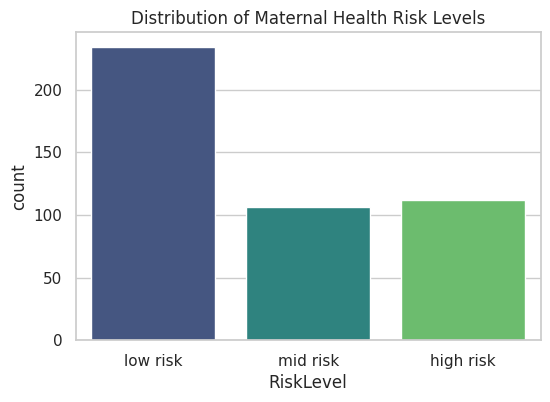

In [3]:

# Set visual style
sns.set_theme(style="whitegrid")

# 1. Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='RiskLevel', data=df, palette='viridis', order=['low risk', 'mid risk', 'high risk'])
plt.title("Distribution of Maternal Health Risk Levels")
plt.show()

## **Feature Distributions by Risk Level (KDE Plots)**

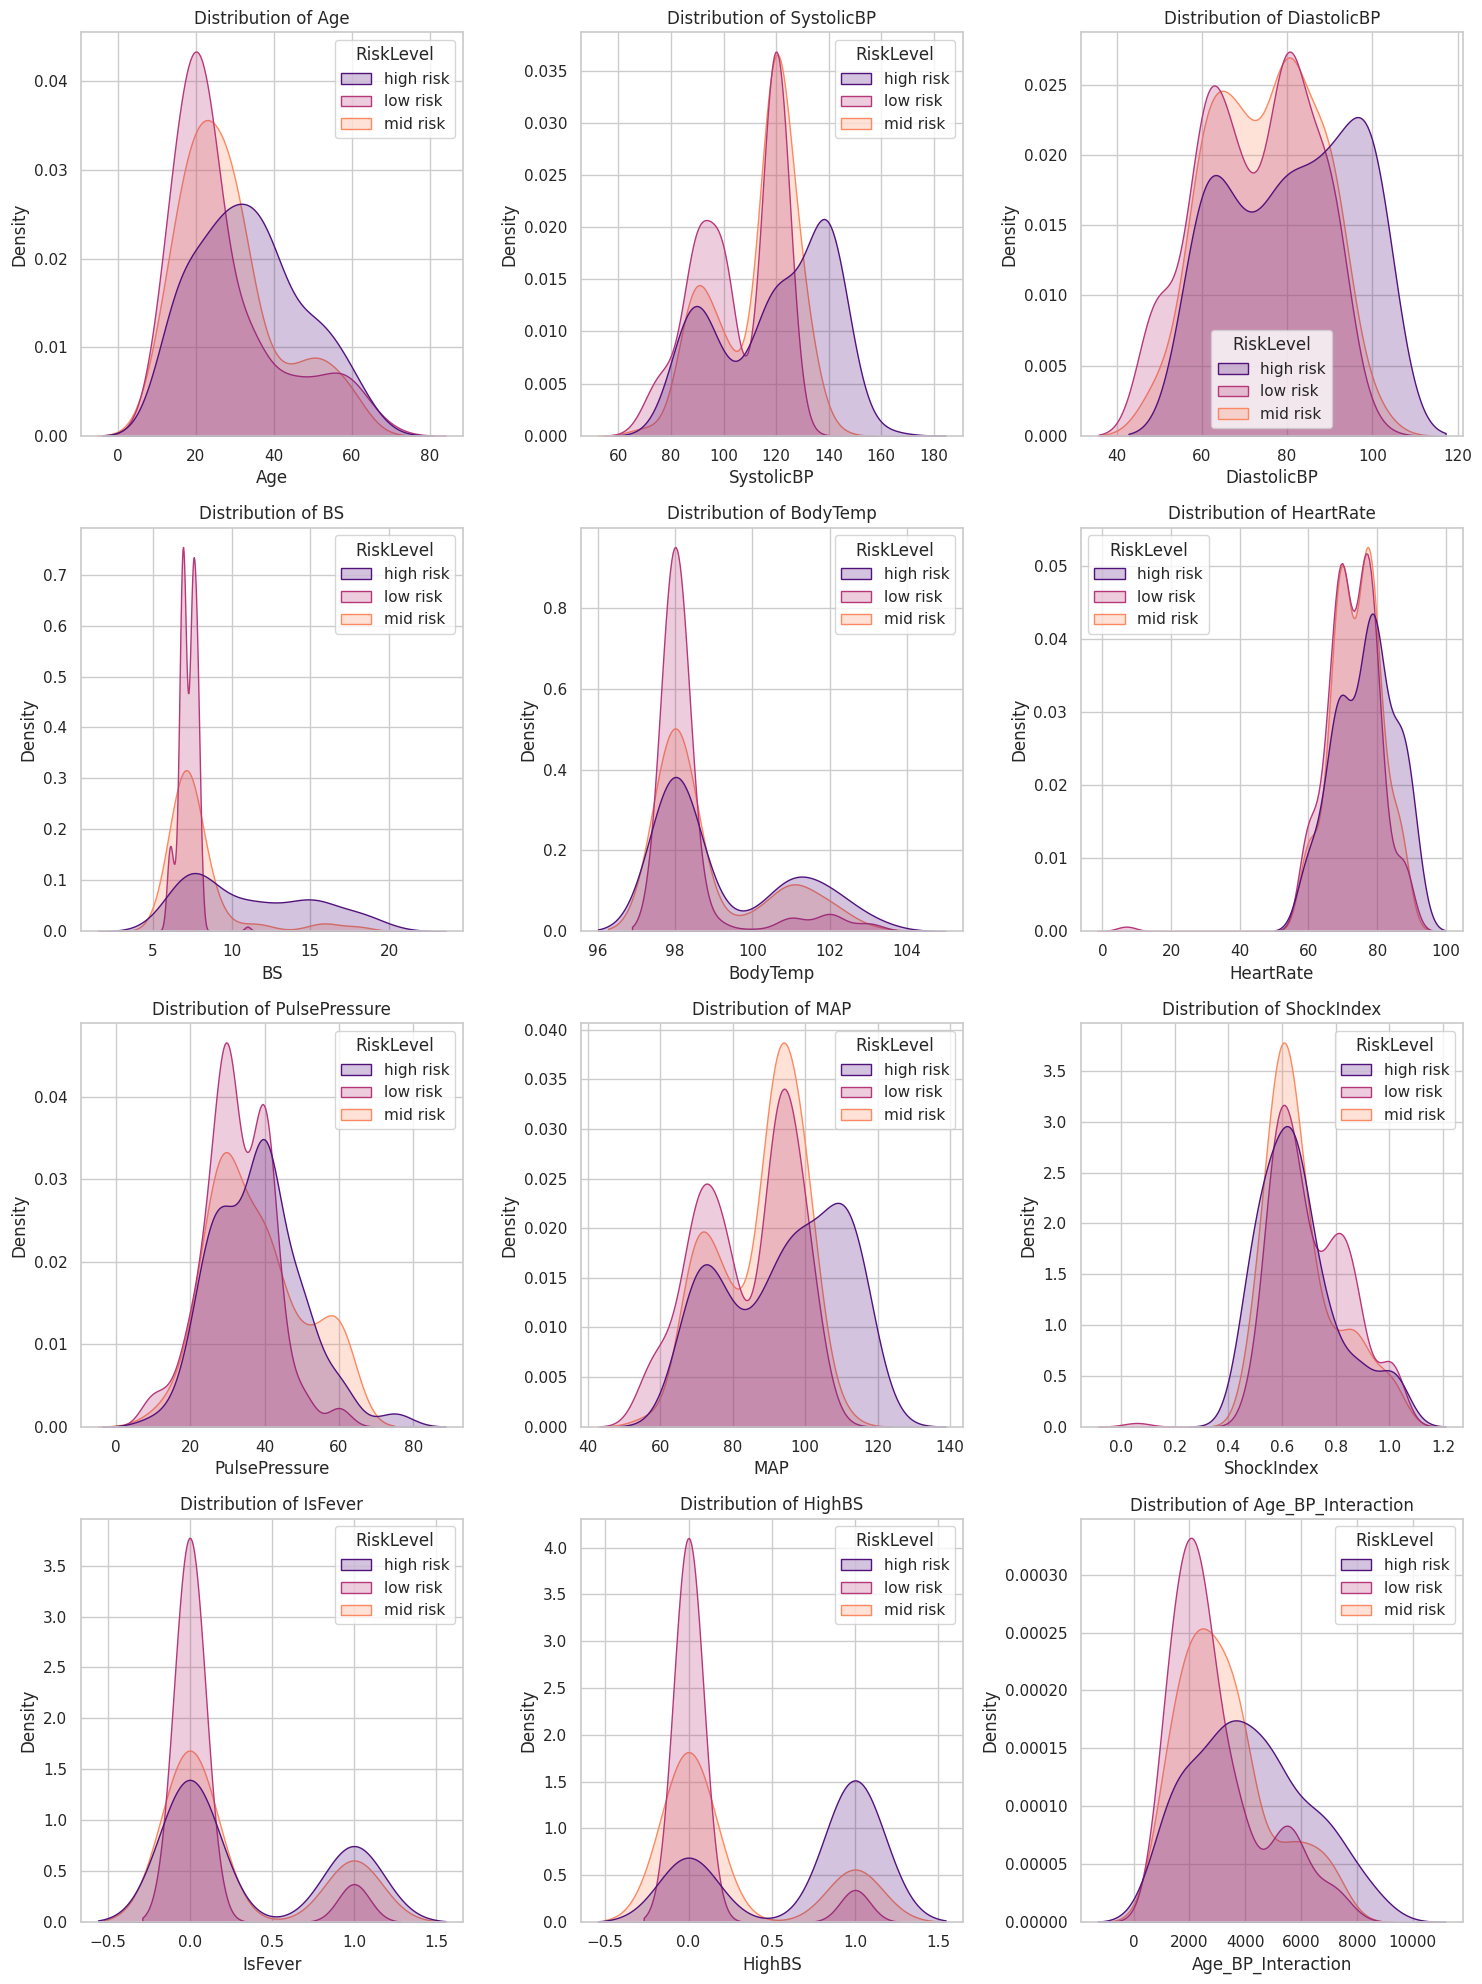

In [12]:
#Feature Distributions by Risk Level (KDE Plots)
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
plt.figure(figsize=(15, 20)) # Adjusted figure size for more plots
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 3, i+1) # Changed to 4 rows, 3 columns to accommodate all 12 plots
    sns.kdeplot(data=df, x=col, hue='RiskLevel', fill=True, common_norm=False, palette='magma')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

## **Correlation Heatmap**

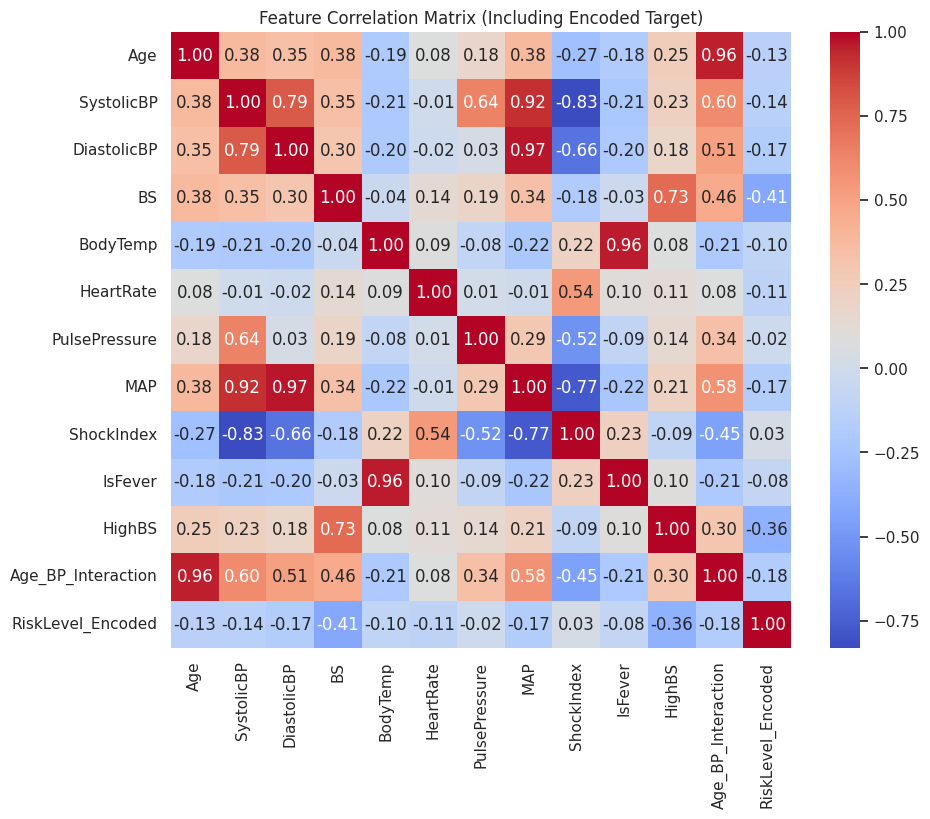

Correlation Mapping:
0 = high risk
1 = low risk
2 = mid risk


In [13]:
# Create a copy and encode the target
temp_df = df.copy()
le_temp = LabelEncoder()
temp_df['RiskLevel_Encoded'] = le_temp.fit_transform(temp_df['RiskLevel'])

# Plotting the heatmap
plt.figure(figsize=(10, 8))

# FIX: Added numeric_only=True to ensure only numbers are calculated
corr_matrix = temp_df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Matrix (Including Encoded Target)")
plt.show()

# Print the mapping so you know what the numbers mean in the heatmap
print("Correlation Mapping:")
for i, cls in enumerate(le_temp.classes_):
    print(f"{i} = {cls}")

# **Train-Test Splitting**

In [14]:
# Define Features (X) and Target (y)
X = df.drop('RiskLevel', axis=1)
y = df['RiskLevel']

# Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (361, 12)
Testing set: (91, 12)


In [15]:
df.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel,PulsePressure,MAP,ShockIndex,IsFever,HighBS,Age_BP_Interaction
0,25,130,80,15.0,98.0,86,high risk,50,96.666667,0.661538,0,1,3250
1,35,140,90,13.0,98.0,70,high risk,50,106.666667,0.500000,0,1,4900
2,29,90,70,8.0,100.0,80,high risk,20,76.666667,0.888889,1,1,2610
3,30,140,85,7.0,98.0,70,high risk,55,103.333333,0.500000,0,0,4200
4,35,120,60,6.1,98.0,76,low risk,60,80.000000,0.633333,0,0,4200


# **Preprocessing**

## **Encoding**

In [16]:
# 1. Encode the Target (Labels to Numbers)
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Mapping:")
for i, cls in enumerate(le.classes_):
    print(f"{cls} → {i}")

Mapping:
high risk → 0
low risk → 1
mid risk → 2


## **Feature Scaling**

In [17]:
#2. Feature Scaling
scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# ONLY transform the test data (using the mean/std from training)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for display
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_train_final.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,PulsePressure,MAP,ShockIndex,IsFever,HighBS,Age_BP_Interaction
0,1.801667,-0.572043,-0.743125,-0.328580,-0.514260,-0.945909,-0.018113,-0.711623,-0.206942,-0.516398,-0.644737,1.177497
1,-0.693298,-0.014968,-1.112132,-0.504429,0.860909,-0.469490,1.344111,-0.711623,-0.368606,1.936492,-0.644737,-0.643540
2,-0.194305,0.542106,-0.374118,-0.574768,-0.514260,0.364242,1.344111,-0.009530,-0.332335,-0.516398,-0.644737,-0.069638
3,-0.123020,0.263569,-1.112132,-0.328580,1.548494,1.436184,1.798186,-0.594608,0.393758,1.936492,-0.644737,-0.080674
4,1.088820,0.542106,1.470918,-0.820957,-0.514260,-0.945909,-0.926262,1.160626,-0.959304,-0.516398,-0.644737,1.122314


# **Machine learning Model**

## **Training the Models**

In [44]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score # Useful for the loop below

models = {
    # Linear Models
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM (SVC)": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

# Training and simple evaluation loop
for name, model in models.items():
    model.fit(X_train_final, y_train_encoded)


    print(f"{name:20} | Status: Trained  ")

Logistic Regression  | Status: Trained  
SVM (SVC)            | Status: Trained  
Gradient Boosting    | Status: Trained  


## **Evaluating the Models**

In [45]:
import time
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():
    # --- Training Phase & Timing ---
    start_train = time.time()
    model.fit(X_train_final, y_train_encoded)
    end_train = time.time()
    train_time = end_train - start_train

    # --- Prediction Phase & Timing ---
    start_test = time.time()
    y_pred = model.predict(X_test_scaled)
    end_test = time.time()
    test_time = end_test - start_test

    # --- Metrics Calculation ---
    acc = accuracy_score(y_test_encoded, y_pred)
    prec = precision_score(y_test_encoded, y_pred, average='weighted')
    rec = recall_score(y_test_encoded, y_pred, average='weighted')
    f1 = f1_score(y_test_encoded, y_pred, average='weighted')

    # Print Detailed Report to Console
    print(f"\n Model: {name}")
    print("-" * 40)
    print(classification_report(y_test_encoded, y_pred, target_names=le.classes_))

    # Store results for the DataFrame
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "Train Time (s)": round(train_time, 4),
        "Test Time (s)": round(test_time, 4)
    })

# --- Final Leaderboard ---
baseline_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
print("\n" + "="*20 + " FINAL LEADERBOARD " + "="*20)
display(baseline_results)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(



 Model: Logistic Regression
----------------------------------------
              precision    recall  f1-score   support

   high risk       0.81      0.57      0.67        23
    low risk       0.63      0.96      0.76        47
    mid risk       0.25      0.05      0.08        21

    accuracy                           0.65        91
   macro avg       0.57      0.52      0.50        91
weighted avg       0.59      0.65      0.58        91


 Model: SVM (SVC)
----------------------------------------
              precision    recall  f1-score   support

   high risk       0.77      0.74      0.76        23
    low risk       0.69      0.89      0.78        47
    mid risk       0.50      0.19      0.28        21

    accuracy                           0.69        91
   macro avg       0.65      0.61      0.60        91
weighted avg       0.67      0.69      0.66        91


 Model: Gradient Boosting
----------------------------------------
              precision    recall  f1-sc

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score,Train Time (s),Test Time (s)
1,SVM (SVC),0.6923,0.6663,0.6923,0.6563,0.0301,0.0028
2,Gradient Boosting,0.6264,0.6161,0.6264,0.6092,0.3779,0.0018
0,Logistic Regression,0.6484,0.5904,0.6484,0.5809,0.0123,0.0006


## **Visalization of evaluations**

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/util

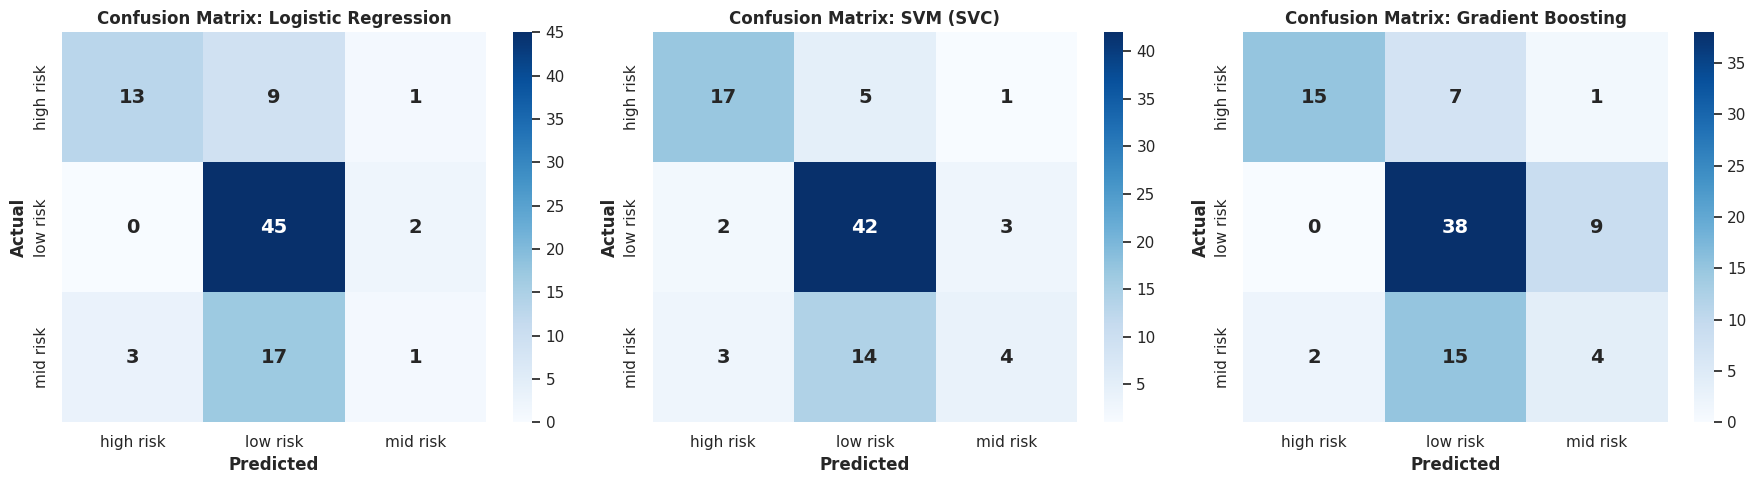

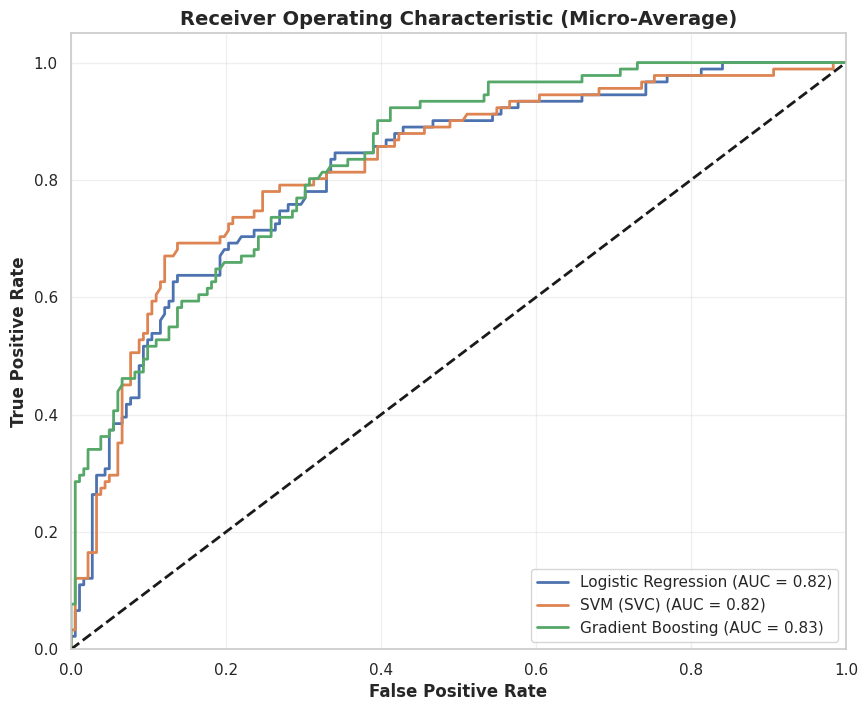

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Setup Plotting for Confusion Matrices
num_models = len(models)
rows = (num_models + 2) // 3
fig_cm, axes = plt.subplots(nrows=rows, ncols=3, figsize=(18, 5 * rows))
axes = axes.flatten()

# 2. Setup Plotting for ROC Curve
plt.figure(figsize=(10, 8))

for i, (name, model) in enumerate(models.items()):
    # --- 1. Confusion Matrix ---
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test_encoded, y_pred)

    # Note: 'annot_kws' bolds the numbers inside the cells
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_,
                annot_kws={"weight": "bold", "size": 14})

    axes[i].set_title(f"Confusion Matrix: {name}", fontweight='bold')
    axes[i].set_ylabel('Actual', fontweight='bold')
    axes[i].set_xlabel('Predicted', fontweight='bold')

    # --- 2. Corrected ROC Curve Logic ---
    # Multi-class ROC requires probability scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)
    else:
        # For models like Linear SVC that don't have predict_proba by default
        y_score = model.decision_function(X_test_scaled)
        # Normalize decision_function to look like probabilities if needed
        y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min())

    # Binarize the output for the 3 classes
    n_classes = len(le.classes_)
    y_test_bin = label_binarize(y_test_encoded, classes=range(n_classes))

    # Compute Micro-average ROC curve
    # This pools all classes together to give a global view of performance
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', lw=2)

# --- Finalize ROC Plot ---
plt.plot([0, 1], [0, 1], 'k--', lw=2) # Diagonal random line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (Micro-Average)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Clean up empty subplots in CM figure
for j in range(i + 1, len(axes)):
    fig_cm.delaxes(axes[j])

fig_cm.tight_layout()
plt.show()

# **Hyperparametr Optimization with Grid Search**

Optimizing Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


Optimizing SVM (SVC)...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


Optimizing Gradient Boosting...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


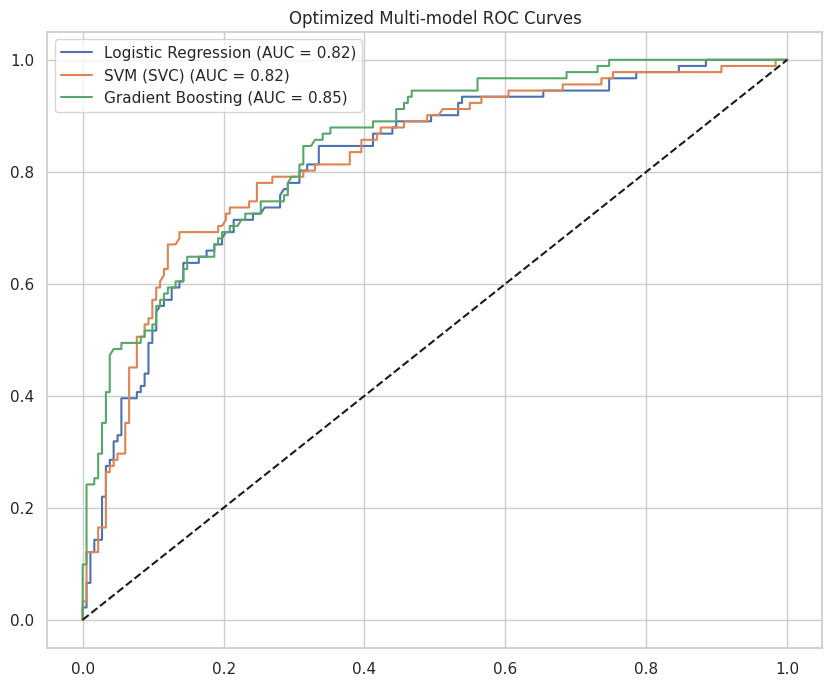

,Model,Best Params,Accuracy,Precision,Recall,F1-Score,Train Time (s)
1,SVM (SVC),"{'C': 1, 'kernel': 'rbf'}",0.6923,0.6663,0.6923,0.6563,0.43
2,Gradient Boosting,"{'learning_rate': 0.05, 'max_depth': 3, 'n_est...",0.6593,0.6517,0.6593,0.6337,5.05
0,Logistic Regression,"{'C': 10, 'penalty': 'l2'}",0.6593,0.5979,0.6593,0.5927,1.78


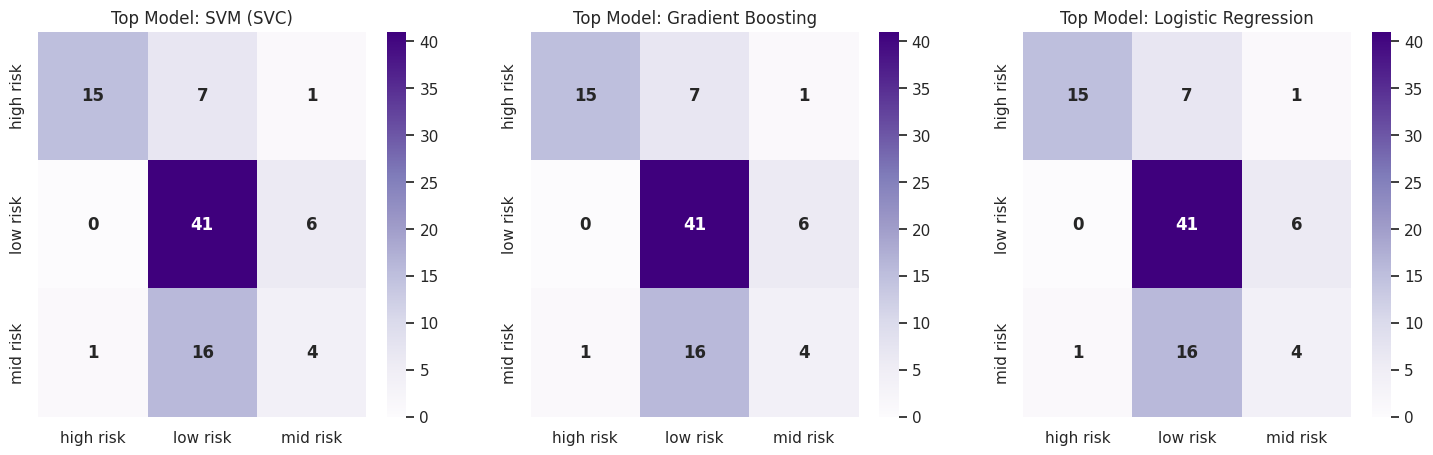

In [48]:
from sklearn.model_selection import GridSearchCV
import time

# 1. Define Models and their specific Parameter Grids
param_grids = {
    "Logistic Regression": {
        'C': [0.1, 1, 10],
        'penalty': ['l2']
    },
    "SVM (SVC)": {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear']
    },
    "Random Forest": {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20]
    },
    "XGBoost": {
        'n_estimators': [100, 200],
        'learning_rate': [0.01, 0.1],
        'max_depth': [3, 5]
    },
    "KNN": {
        'n_neighbors': [3, 5, 11],
        'weights': ['uniform', 'distance']
    },
    "Decision Tree": {
        'max_depth': [None, 5, 10, 20],
        'criterion': ['gini', 'entropy']
    },
    "Gradient Boosting": {
        'n_estimators': [100],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5]
    },
    "Naive Bayes": {} # No major hyperparameters to tune for GaussianNB
}

optimized_results = []
plt.figure(figsize=(10, 8)) # For the combined ROC Curve

# 2. Loop through each model and perform GridSearch
for name, model in models.items():
    print(f"Optimizing {name}...")

    grid = GridSearchCV(
        model,
        param_grids.get(name, {}),
        cv=3,
        scoring='f1_weighted',
        n_jobs=-1
    )

    start_time = time.time()
    grid.fit(X_train_final, y_train_encoded)
    train_time = time.time() - start_time

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test_scaled)

    # Calculate Metrics
    acc = accuracy_score(y_test_encoded, y_pred)
    prec = precision_score(y_test_encoded, y_pred, average='weighted')
    rec = recall_score(y_test_encoded, y_pred, average='weighted')
    f1 = f1_score(y_test_encoded, y_pred, average='weighted')

    optimized_results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "Train Time (s)": round(train_time, 2)
    })

    # --- ROC Curve Plotting ---
    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(X_test_scaled)
    else:
        y_score = best_model.decision_function(X_test_scaled)

    y_test_bin = label_binarize(y_test_encoded, classes=range(len(le.classes_)))
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

# 3. Finalize ROC Plot
plt.plot([0, 1], [0, 1], 'k--')
plt.title("Optimized Multi-model ROC Curves")
plt.legend()
plt.show()

# 4. Display Final Table
optimized_df = pd.DataFrame(optimized_results).sort_values(by="F1-Score", ascending=False)
display(optimized_df)

# 5. Show Confusion Matrices for Top 3 Models
top_3 = optimized_df['Model'].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, name in enumerate(top_3):
    # Re-run prediction for top 3
    # (Note: In a production script, you'd store the best_model objects in a dict)
    best_m = [m for m in optimized_results if m['Model'] == name][0]
    # Re-fitting/Predicting for visualization simplicity:
    cm = confusion_matrix(y_test_encoded, y_pred) # y_pred from last loop
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[idx],
                xticklabels=le.classes_, yticklabels=le.classes_,
                annot_kws={"weight": "bold"})
    axes[idx].set_title(f"Top Model: {name}")

# **Handling Class Imbalance using SMOTE**

In [55]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Initialize SMOTE
smote = SMOTE(random_state=42)

# 2. Resample the scaled training data
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Before SMOTE: {Counter(y)}")
print(f"After SMOTE:  {Counter(y_resampled)}")

# This X_resampled and y_resampled will be used for the training below

Before SMOTE: Counter({'low risk': 234, 'high risk': 112, 'mid risk': 106})
After SMOTE:  Counter({'high risk': 234, 'low risk': 234, 'mid risk': 234})


/tmp/ipykernel_238/493130613.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(before.keys()), y=list(before.values()), ax=ax[0], palette='viridis')
/tmp/ipykernel_238/493130613.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(after.keys()), y=list(after.values()), ax=ax[1], palette='magma')


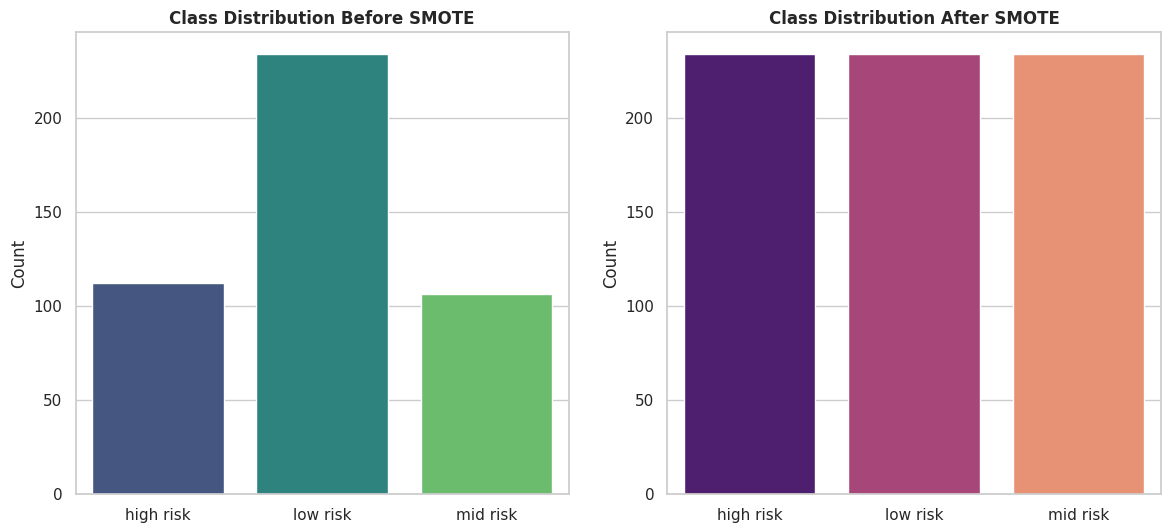

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data for plotting
before = Counter(y.iloc[:, 0] if isinstance(y, pd.DataFrame) else y)
after = Counter(y_resampled)

# Plotting
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=list(before.keys()), y=list(before.values()), ax=ax[0], palette='viridis')
ax[0].set_title("Class Distribution Before SMOTE", fontweight='bold')
ax[0].set_ylabel("Count")

sns.barplot(x=list(after.keys()), y=list(after.values()), ax=ax[1], palette='magma')
ax[1].set_title("Class Distribution After SMOTE", fontweight='bold')
ax[1].set_ylabel("Count")

plt.show()

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Encode the target labels (High, Mid, Low -> 0, 1, 2)
le = LabelEncoder()
y_resampled_encoded = le.fit_transform(y_resampled)

# 2. Split the data
# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled_encoded, test_size=0.2, random_state=42
)

# 3. Initialize and fit the Scaler
scaler = StandardScaler()

# Fit only on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Final Training shape: {X_train_scaled.shape}")
print(f"Final Testing shape: {X_test_scaled.shape}")

Final Training shape: (561, 12)
Final Testing shape: (141, 12)


## **Training and Evaluating after class balancing**

In [58]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

# 1. Using the Best Params from your Grid Search
# Note: Ensure these parameters match your specific Grid Search output
optimized_models = {
    "SVM (SVC)": SVC(
        C=1,
        kernel='rbf',
        probability=True,
        class_weight='balanced',
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        learning_rate=0.05,
        max_depth=3,
        n_estimators=100,
        random_state=42
    ),
    "Logistic Regression": LogisticRegression(
        C=10,
        penalty='l2',
        max_iter=2000,
        class_weight='balanced',
        random_state=42
    ),
}

final_results = []

# 2. Iterative Evaluation
for name, model in optimized_models.items():
    # IMPORTANT: Train on the SCALED version of the resampled training data
    # Assuming X_train_scaled and y_train come from the split of your resampled data
    model.fit(X_train_scaled, y_train)

    # Predict on the Scaled Test set
    y_pred = model.predict(X_test_scaled)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    b_acc = balanced_accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')

    final_results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Balanced Acc": round(b_acc, 4),
        "F1-Score": round(f1, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4)
    })

# 3. Create Leaderboard
performance_df = pd.DataFrame(final_results).sort_values(by="Accuracy", ascending=False)

print("--- Final Model Evaluation (Grid Search Params + Scaled Data) ---")
display(performance_df)

--- Final Model Evaluation (Grid Search Params + Scaled Data) ---


,Model,Accuracy,Balanced Acc,F1-Score,Precision,Recall
1,Gradient Boosting,0.7660,0.7818,0.7584,0.7681,0.7660
0,SVM (SVC),0.6383,0.6563,0.6268,0.6362,0.6383
2,Logistic Regression,0.5887,0.6058,0.5798,0.5839,0.5887


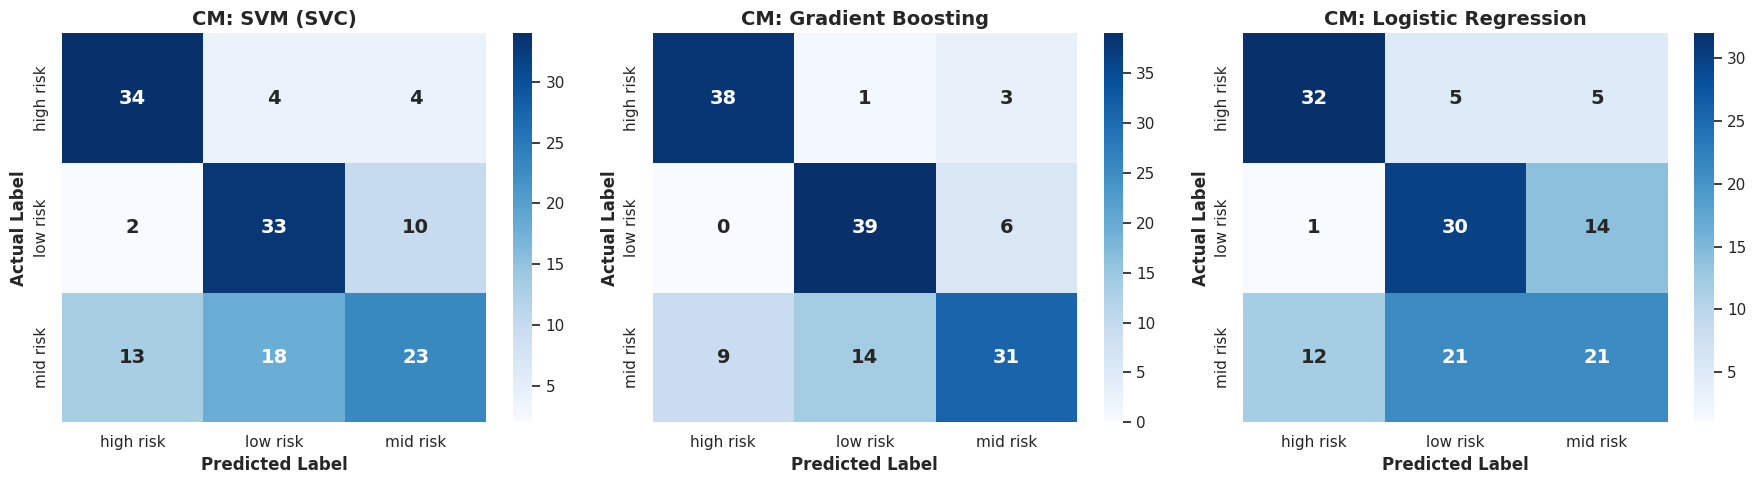

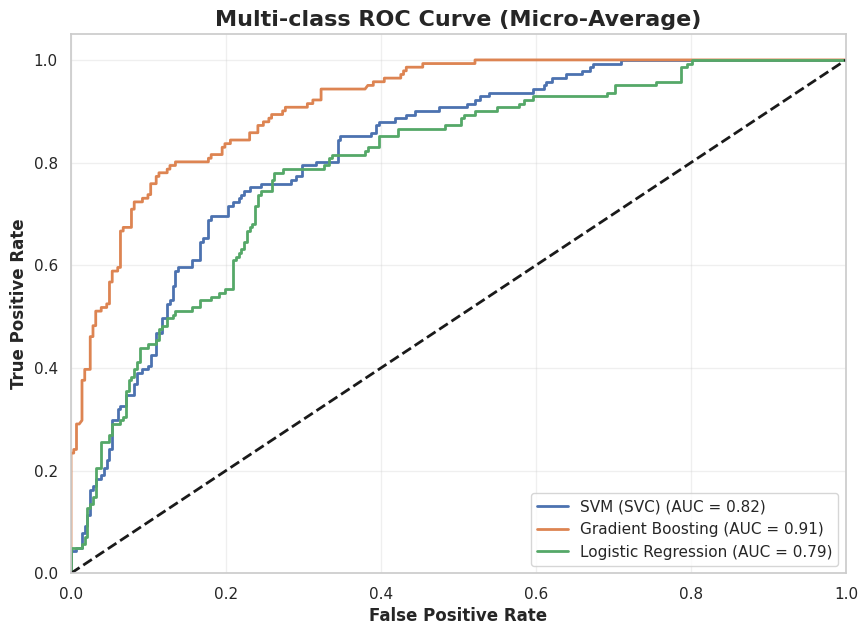

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# --- 1. Setup Plotting for Confusion Matrices ---
num_models = len(optimized_models)
cols = 3
rows = (num_models + cols - 1) // cols
fig_cm, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(18, 5 * rows))
axes = axes.flatten()

# --- 2. Setup Plotting for ROC Curve ---
plt.figure(figsize=(10, 7))

for i, (name, model) in enumerate(optimized_models.items()):
    # Predict for CM
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    # Plot Heatmap (Bolding text with annot_kws)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=le.classes_, yticklabels=le.classes_,
                annot_kws={"weight": "bold", "size": 14})

    axes[i].set_title(f"CM: {name}", fontweight='bold', fontsize=14)
    axes[i].set_ylabel('Actual Label', fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontweight='bold')

    # --- ROC Curve Calculation ---
    # Get probability scores
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test_scaled)
    else:
        y_score = model.decision_function(X_test_scaled)
        # Normalize scores to 0-1 range for ROC
        y_score = (y_score - y_score.min()) / (y_score.max() - y_score.min())

    # Binarize y_test for multi-class ROC
    n_classes = len(le.classes_)
    y_test_bin = label_binarize(y_test, classes=range(n_classes))

    # Compute Micro-average ROC
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})', lw=2)

# Finalize Confusion Matrix Layout
for j in range(i + 1, len(axes)):
    fig_cm.delaxes(axes[j])
fig_cm.tight_layout()

# Finalize ROC Plot
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('Multi-class ROC Curve (Micro-Average)', fontweight='bold', fontsize=16)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

# **Cross Validation**

In [61]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_validate
# 1. Prepare the resampled data (Fixing the NameError)
# We need to scale the X_resampled you created with SMOTE
scaler = StandardScaler()
X_resampled_scaled = scaler.fit_transform(X_resampled)

# Ensure y is encoded as integers (0, 1, 2)
le = LabelEncoder()
y_resampled_encoded = le.fit_transform(y_resampled)
# 1. Initialize K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 2. Define Metrics
scoring_metrics = {
    'accuracy': 'accuracy',
    'f1_weighted': 'f1_weighted',
    'recall_weighted': 'recall_weighted'
}

cv_detailed_results = []

# 3. Process Models
for name, model in optimized_models.items():
    # Perform Cross-Validation
    cv_results = cross_validate(
        model,
        X_resampled_scaled,
        y_resampled_encoded,
        cv=skf,
        scoring=scoring_metrics
    )

    # Extract Means and Standard Deviations
    acc_mean = np.mean(cv_results['test_accuracy'])
    acc_std = np.std(cv_results['test_accuracy'])

    f1_mean = np.mean(cv_results['test_f1_weighted'])
    f1_std = np.std(cv_results['test_f1_weighted'])

    rec_mean = np.mean(cv_results['test_recall_weighted'])
    rec_std = np.std(cv_results['test_recall_weighted'])

    cv_detailed_results.append({
        "Model": name,
        "Accuracy (Mean)": round(acc_mean, 4),
        "Accuracy (Std)": round(acc_std, 4),
        "F1-Score (Mean)": round(f1_mean, 4),
        "F1-Score (Std)": round(f1_std, 4),
        "Recall (Mean)": round(rec_mean, 4),
        "Recall (Std)": round(rec_std, 4)
    })

# 4. Display Final Table
cv_performance_df = pd.DataFrame(cv_detailed_results).sort_values(by="Accuracy (Mean)", ascending=False)
print("--- K-Fold Cross-Validation: Mean & Standard Deviation ---")
display(cv_performance_df)

--- K-Fold Cross-Validation: Mean & Standard Deviation ---


,Model,Accuracy (Mean),Accuracy (Std),F1-Score (Mean),F1-Score (Std),Recall (Mean),Recall (Std)
1,Gradient Boosting,0.7464,0.0247,0.7439,0.0213,0.7464,0.0247
0,SVM (SVC),0.6766,0.0193,0.6634,0.0234,0.6766,0.0193
2,Logistic Regression,0.6482,0.0299,0.6437,0.0315,0.6482,0.0299


# **Model Explainability using Explainable AI**
## **Feature Importance**

## **SHAP based analysis**

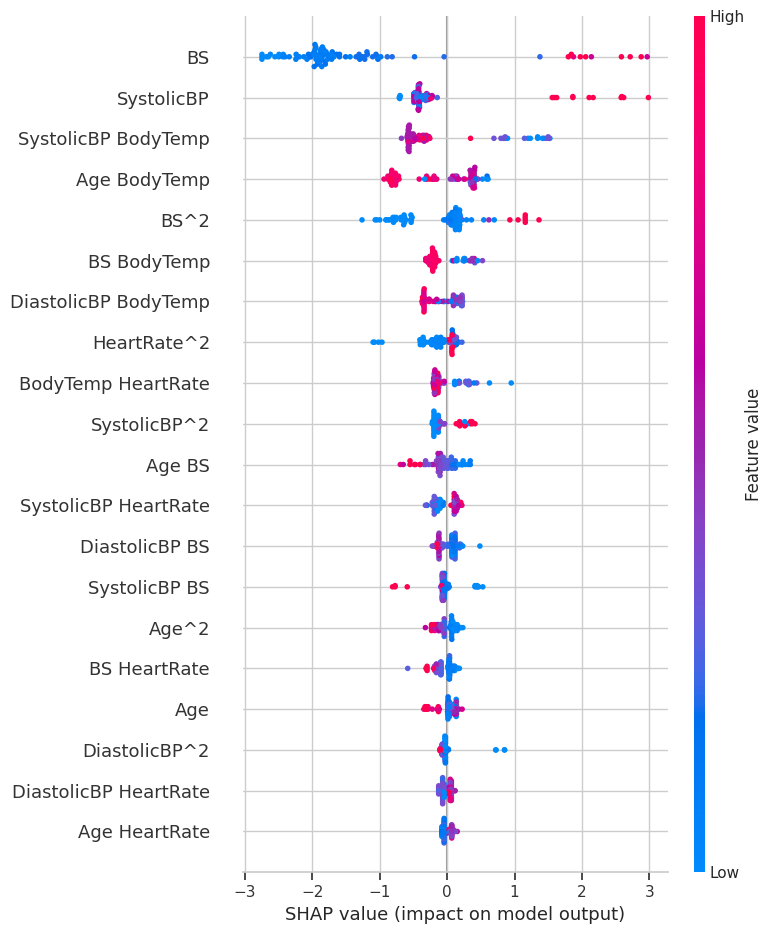

In [ ]:
import shap

# 1. Initialize the SHAP explainer for Gradient Boosting
explainer = shap.TreeExplainer(gb_model)

# 2. Calculate SHAP values for the test set
# We use a slice of 100-200 samples if your dataset is very large to save time
shap_values = explainer.shap_values(X_test_g)

# 3. Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_g, feature_names=poly_features_names)

## **Patient-Level Diagnosis (Waterfall Plot)**

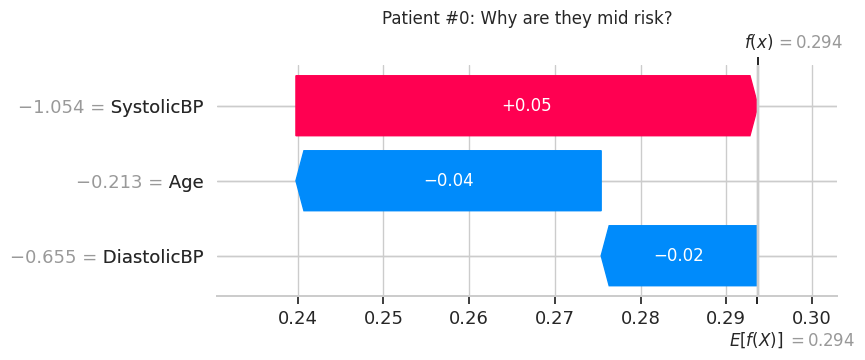

In [73]:
import shap
import matplotlib.pyplot as plt

# 1. Identify your data variable
# If 'X_test_g' failed, we use 'X_test_scaled' or 'X_test' from your earlier split
data_for_explanation = X_test_scaled  # Or X_test if you kept it as a DataFrame

# 2. Select a specific patient and Class (2 = High Risk)
patient_idx = 0
class_idx = 2

# 3. Create the Explanation Object
# This object is required for Waterfall and Beeswarm plots
exp = shap.Explanation(
    values=shap_values[class_idx][patient_idx],
    base_values=explainer.expected_value[class_idx],
    data=data_for_explanation[patient_idx],
    feature_names=X.columns.tolist() # Using original column names
)

# --- PLOT 1: Waterfall Plot (Individual Diagnosis) ---
plt.figure(figsize=(10, 6))
plt.title(f"Patient #{patient_idx}: Why are they {le.classes_[class_idx]}?")
shap.plots.waterfall(exp)


## **Heatmap (Population Patterns)**
The heatmap is excellent for spotting "Patient Phenotypes." It stacks individual waterfall plots horizontally, allowing you to see if one group of patients is high-risk due to Blood Pressure while another is high-risk due to Age/BS.

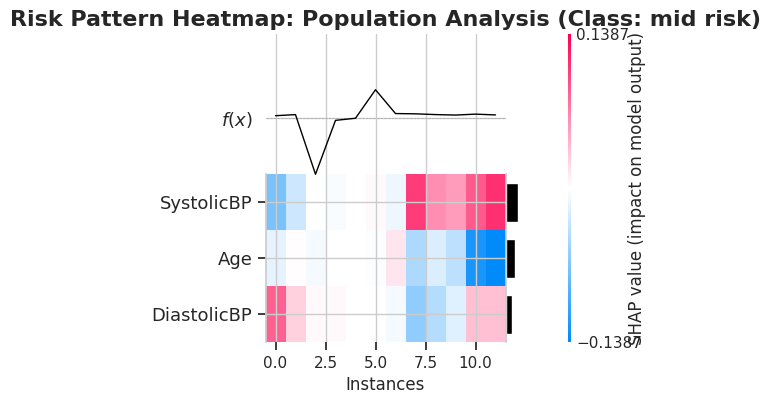

In [76]:
# Create an Explanation object for a group of patients (e.g., first 100)
# This is required for the modern heatmap plot
subset_size = 100
heatmap_exp = shap.Explanation(
    values=high_risk_shap_values[:subset_size],
    base_values=explainer.expected_value[class_idx],
    data=data_for_explanation[:subset_size],
    feature_names=X.columns.tolist()
)

plt.figure(figsize=(12, 8))
# The plot will show features on the Y-axis and individual patients on the X-axis
shap.plots.heatmap(heatmap_exp, show=False)
plt.title(f"Risk Pattern Heatmap: Population Analysis (Class: {le.classes_[class_idx]})", fontsize=16, fontweight='bold')
plt.show()